# Линейная регрессия и регуляризация: реализация с нуля

**Учебно-исследовательский проект** | НИУ ВШЭ, ФКН, ОП «Прикладная математика и информатика», 1 курс

## О проекте

 Разбор линейной регрессии: я реализую метод наименьших квадратов (МНК) и L2-регуляризацию через прямые матричные формулы. Цель —  понять, что именно происходит при её обучении, какие у неё есть проблемы и как их решает регуляризация.

## Что внутри

1. **МНК с нуля** на синтетических данных. Реализация через формулу $a = (X^\top X)^{-1} X^\top y$, аппроксимация полиномами разных степеней, демонстрация эффекта переобучения.
2. **Многомерная линейная регрессия** на реальных данных о ценах квартир в Москве. Базовая модель + feature engineering (произведения признаков, логарифмы) с обоснованием через корреляционный анализ.
3. **L2-регуляризация (гребневая регрессия)**. Реализация через $a = (X^\top X + \lambda I)^{-1} X^\top y$, подбор $\lambda$ по отдельной валидационной выборке, теоретический разбор почему $\det(X^\top X + \lambda I) > 0$, и что происходит при $\text{rk}\, X < k$.
4. **Онлайн-обучение** регрессии через инкрементальное обновление накапливаемых матриц $X^\top X$ и $X^\top y$. Сложность $O(k^2)$ на шаг, не зависит от числа уже виденных объектов.

## Стек

`numpy` (для всех вычислений), `pandas` (загрузка данных), `matplotlib`/`seaborn` (визуализация), `sympy` (красивая печать многочленов), `sklearn.model_selection.train_test_split` (только для разбиения выборки).

## Часть 1. МНК и эффект переобучения на синтетических данных

В качестве разминки — задача о том, чтобы по зашумлённым точкам восстановить неизвестную функцию. Начинаю с прямой, продолжаю полиномами всё более высоких степеней, и наблюдаю классический эффект переобучения.

### Постановка задачи МНК

Рассмотрим систему $Xa = y$, в которой $a$ — столбец неизвестных. Если правая часть не лежит в столбцовом пространстве матрицы $X$, точного решения нет. МНК ищет такой вектор $\hat a$, который минимизирует квадрат евклидовой нормы невязки:

$$\hat a = \arg\min_a \|Xa - y\|^2.$$

Дифференцируя и приравнивая градиент к нулю, получаем нормальное уравнение $X^\top X a = X^\top y$, откуда при невырожденной $X^\top X$:

$$\hat a = (X^\top X)^{-1} X^\top y.$$

Для приближения многочленом степени $k$ матрица $X$ — это матрица Вандермонда: в столбцах стоят степени $x$ от $0$ до $k$.

### Загрузка данных

Данные — две выборки точек: обучающая `train.txt` и тестовая `test.txt`, каждая в виде двух колонок $(x_i, y_i)$, где $y_i = f(x_i) + \varepsilon_i$ для неизвестной функции $f$ и шума $\varepsilon$.

In [1664]:
import numpy as np

data_train_1 = np.loadtxt('data/train.txt', delimiter=',')
data_test_1 = np.loadtxt('data/test.txt', delimiter=',')

In [1665]:
X_test = data_test_1[:,0]
y_test = data_test_1[:,1]

# Сделайте то же для тестовой выборки
X_train = data_train_1[:,0]
y_train = data_train_1[:,1]

### Линейная аппроксимация

Реализую МНК как функцию, которая принимает данные и степень многочлена, и возвращает коэффициенты. Для степени $k$ строю матрицу из степеней $x^0, x^1, \ldots, x^k$ и применяю прямую формулу.

In [1666]:
import sympy as sp

def MNK(X, y, deg):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    XB = np.hstack([X ** i for i in range(deg + 1)]) 
    
    coeffs = np.linalg.inv(XB.T @ XB) @ XB.T @ y
    
    return coeffs

coeffs = MNK(X_train, y_train, 1)
x = sp.symbols('x')
poly = sp.expand(sum(c * x ** i for i, c in enumerate(coeffs[::-1])))
sp.pprint(poly)

4.43323090506494⋅x + 2.27913449805195


Визуализирую полученную прямую вместе с обучающими и тестовыми точками.

2.2791344980519463 4.433230905064936


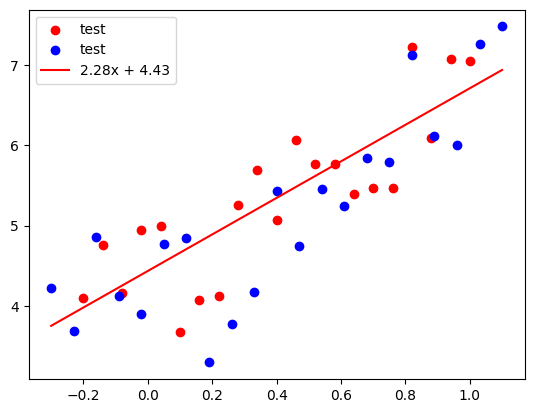

In [1667]:
import matplotlib.pyplot as plt

k, b = coeffs[::-1]
print(k, b)
big_x, big_y = np.concatenate([X_train, X_test]), np.concatenate([y_train, y_test])
x_line = np.linspace(big_x.min(), big_x.max(), 100)
x_line_train = np.linspace(X_test.min(), X_test.max(), 100)
x_line_test = np.linspace(X_test.min(), X_test.max(), 100)
y_line = k * x_line + b

plt.scatter(X_train, y_train, color='red', label='test')
plt.scatter(X_test, y_test, color='blue', label='test')
plt.plot(x_line, y_line, color='red', label=f'{k:.2f}x + {b:.2f}')
plt.legend()
plt.show()

### Интерполяционный многочлен

Если взять степень многочлена равной $n - 1$ (где $n$ — число обучающих точек), он пройдёт ровно через все обучающие точки и MSE на обучающей выборке будет равна нулю. Это именно интерполяционный многочлен Лагранжа: при подстановке матрицы Вандермонда полной степени в МНК получаются коэффициенты Лагранжева многочлена.

Использую `np.polyfit` вместо самописного МНК — он использует численно более стабильный алгоритм через QR/SVD, что важно при высоких степенях, где матрица Вандермонда плохо обусловлена.

In [1668]:
import sympy as sp


coeffs = np.polyfit(X_train, y_train, deg=X_train.shape[0] - 1)


p = np.poly1d(coeffs)
poly = sum(sp.Rational(c).limit_denominator(1000) * x**i 
           for i, c in enumerate(coeffs[::-1]))

poly_simplified = sp.expand(poly)
mse_train = np.mean((p(X_train) - y_train) ** 2)

sp.pprint(f"{poly_simplified} : mse - {mse_train} <- MSE через МНК == интерполяционный многочлен (пользуюсь полифит так как он использует более стабильную структуру МНК - через просто матричное уравнение эта штука разгоняется сильно)")

-12940247561623*x**20/927 + 57948887478209*x**19/619 - 261288270809923*x**18/9 ↪

↪ 85 + 216333698428760*x**17/553 - 34975011464061*x**16/137 - 99208562170660*x ↪

↪ **15/889 + 355751345778515*x**14/888 - 407557227509333*x**13/1000 + 20382451 ↪

↪ 3675454*x**12/867 - 76068768534907*x**11/958 + 9656537758833*x**10/830 + 190 ↪

↪ 3656624955*x**9/994 - 233015798310*x**8/197 + 148891151734*x**7/839 + 511132 ↪

↪ 2382*x**6/941 - 3340235003*x**5/752 + 126680970*x**4/359 + 5171293*x**3/326  ↪

↪ - 1572486*x**2/599 + 20318*x/741 + 1973/299 : mse - 0.00704111003750198 <- M ↪

↪ SE через МНК == интерполяционный многочлен (пользуюсь полифит так как он исп ↪

↪ ользует более стабильную структуру МНК - через просто матричное уравнение эт ↪

↪ а штука разгоняется сильно)


/var/folders/4x/b_fglbm961qbxmcz5df0xqpr0000gn/T/ipykernel_80580/459143758.py:5: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(X_train, y_train, deg=X_train.shape[0] - 1)


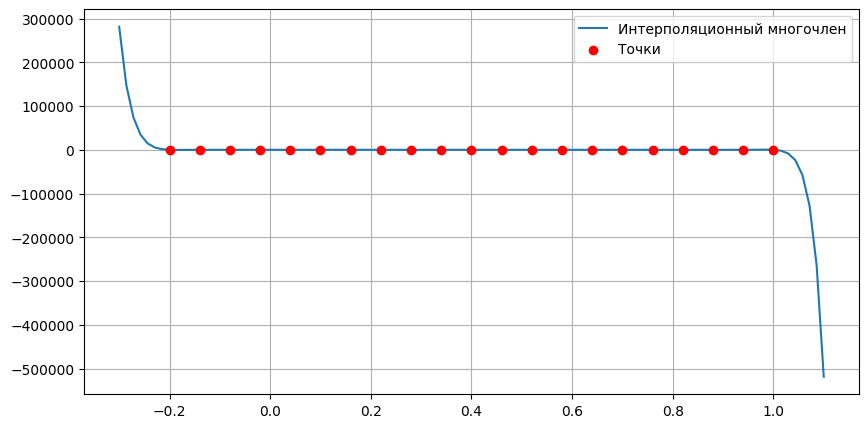

In [1669]:
plt.figure(figsize=(10, 5))
plt.plot(x_line_train, p(x_line_train), label='Интерполяционный многочлен')
plt.scatter(X_train, y_train, color='red', zorder=5, label='Точки')
plt.legend()
plt.grid(True)
plt.show()

### Полиномы степеней от 1 до 10

Для каждой степени от 1 до 10 строю многочлен через свой `MNK` и считаю MSE на обучающей и тестовой выборках.

In [1670]:
x = sp.symbols('x')
for k in range(1, 11):
    coeffs = MNK(X_train, y_train, deg=k)
    p = np.poly1d(coeffs)

    poly = sum(sp.Rational(c).limit_denominator(1000) * x**i 
            for i, c in enumerate(coeffs[::-1]))

    poly_simplified = sp.expand(poly)
    sp.pprint(f"k = {k}: {poly_simplified}")

k = 1: 4349*x/981 + 841/369
k = 2: 975*x**2/218 + 961*x/830 + 1033/737
k = 3: 3863*x**3/866 + 344*x**2/323 + 1631*x/877 - 289/757
k = 4: 4250*x**4/979 + 989*x**3/844 + 6665*x**2/981 - 7374*x/565 + 7673/969
k = 5: 1161*x**5/262 - 35*x**4/268 + 3147*x**3/961 + 13060*x**2/611 - 27611*x/ ↪

↪ 540 + 28964/981
k = 6: 2056*x**6/469 - 2933*x**5/638 + 11026*x**4/689 + 76877*x**3/634 - 40398 ↪

↪ 7*x**2/839 + 211649*x/364 - 223301/971
k = 7: 4409*x**7/992 - 2253*x**6/562 + 4387*x**5/608 + 22796*x**4/191 - 300405 ↪

↪ *x**3/956 + 71638*x**2/583 + 75429*x/316 - 165206/987
k = 8: 541*x**8/116 - 2467*x**7/476 - 614*x**6/23 + 267785*x**5/996 + 43189*x* ↪

↪ *4/393 - 1942371*x**3/620 + 236622*x**2/35 - 5097329*x/894 + 1698347/982
k = 9: 3949*x**9/850 - 1598*x**8/351 - 2863*x**7/118 + 46875*x**6/214 + 47410* ↪

↪ x**5/269 - 788754*x**4/323 + 1033103*x**3/264 - 952480*x**2/783 - 281588*x/1 ↪

↪ 85 + 675605/748
k = 10: 4361*x**10/934 - 1717*x**9/795 - 23297*x**8/644 + 24041*x**7/535 + 871 ↪

↪ 411*x**6/7

In [1671]:
x = sp.symbols('x')
for k in range(1, 11):
    coeffs = MNK(X_train, y_train, deg=k)
    p = np.poly1d(coeffs)

    poly = sum(sp.Rational(c).limit_denominator(1000) * x**i 
            for i, c in enumerate(coeffs[::-1]))
    mse_train = np.mean((p(X_train) - y_train) ** 2)
    mse_test = np.mean((p(X_test) - y_test) ** 2)
    print(f"k = {k}: train - {mse_train} | test - {mse_test} ")

k = 1: train - 2.5798412479700037 | test - 2.38587484378258 
k = 2: train - 5.923879651812799 | test - 4.547002062375259 
k = 3: train - 15.930284518510044 | test - 13.725624828317812 
k = 4: train - 7.893441525186788 | test - 11.799934838408523 
k = 5: train - 272.8580772636829 | test - 362.78984802132425 
k = 6: train - 25470.126154428202 | test - 35595.216420023484 
k = 7: train - 12650.080754691964 | test - 14289.817283392498 
k = 8: train - 1499473.4982166179 | test - 2402262.7300853245 
k = 9: train - 321252.8028392218 | test - 365963.5734468178 
k = 10: train - 55723346.22798828 | test - 101686704.4990409 


Визуализирую графики полиномов степеней 1–6 поверх тестовой и обучающей выборок.

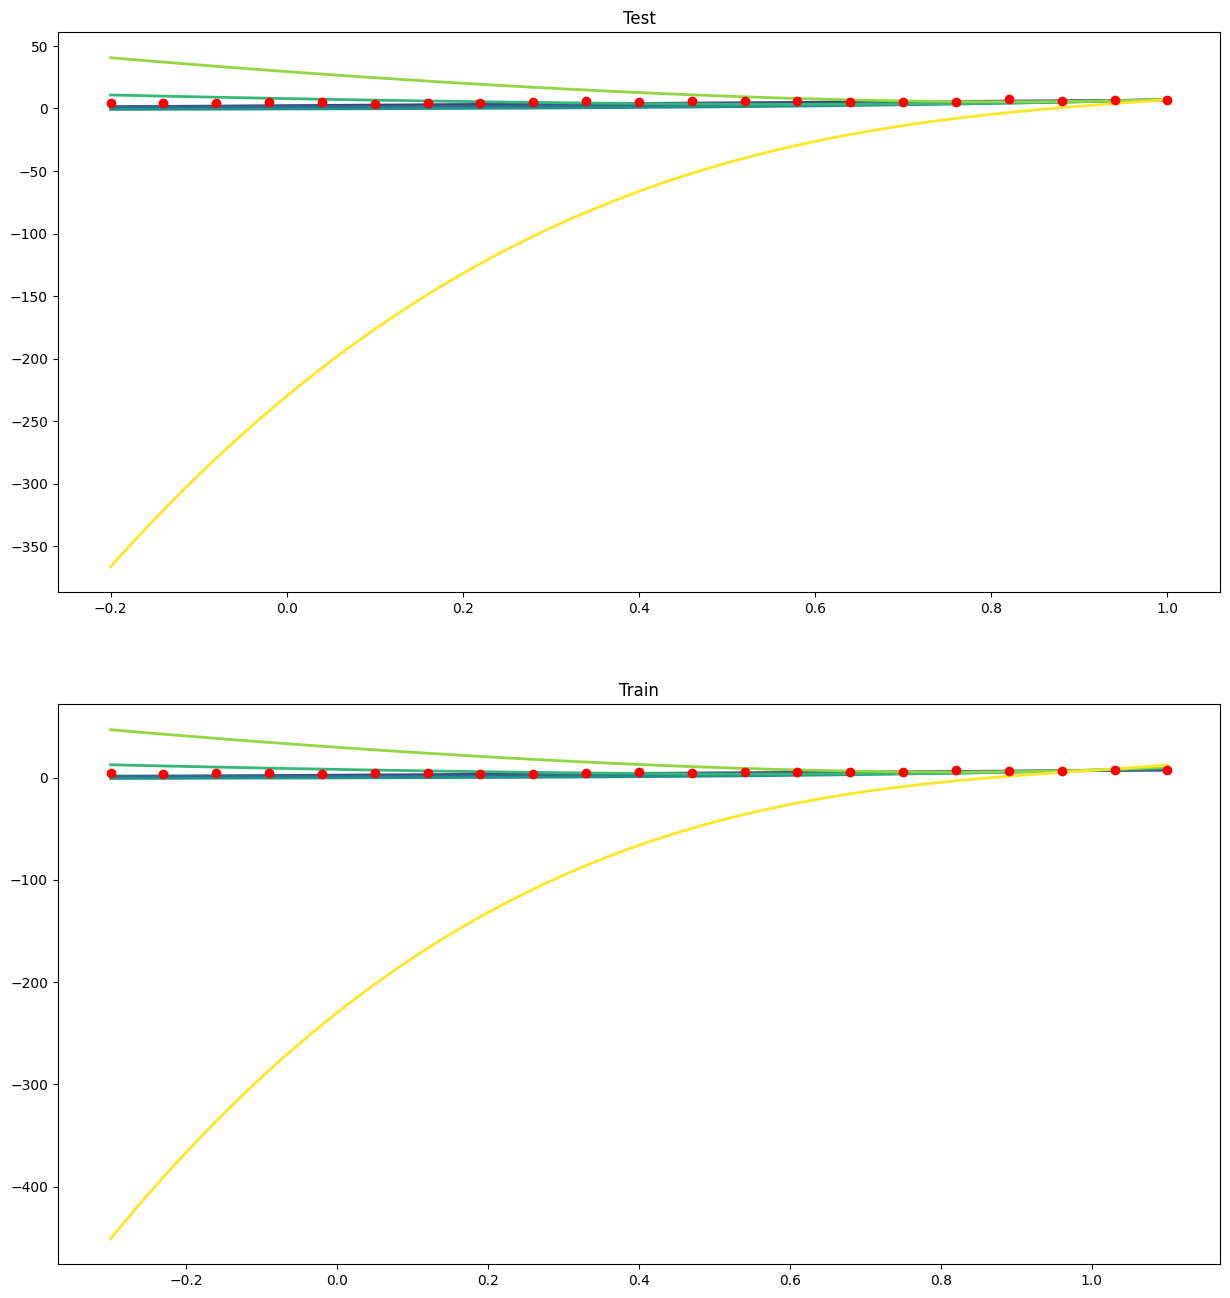

In [1672]:
colors = plt.cm.viridis(np.linspace(0, 1, 7)) 
x_line_train = np.linspace(X_train.min(), X_train.max(), 100)
x_line_test = np.linspace(X_test.min(), X_test.max(), 100)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))
ax1.set_title("Test")
ax2.set_title("Train")
ax1.scatter(X_train, y_train, color='red', zorder=5, label='точки')
ax2.scatter(X_test, y_test, color='red', zorder=5, label='точки')

for k in range(1, 7):
    coeffs = MNK(X_train, y_train, deg=k)
    p = np.poly1d(coeffs)

    poly = sum(sp.Rational(c).limit_denominator(1000) * x**i 
            for i, c in enumerate(coeffs[::-1]))
    ax1.plot(x_line_train, p(x_line_train), label=f"Многочлен степени {k}", color=colors[k], linewidth=2)
    ax2.plot(x_line_test, p(x_line_test), label=f"Многочлен степени {k}", color=colors[k], linewidth=2)

### Вывод по части 1: переобучение

С ростом степени многочлена ошибка на обучающей выборке монотонно падает (что естественно — больше параметров, лучше подгонка под обучающий шум), а ошибка на тестовой выборке сначала падает, потом растёт. После $k = 10$ ошибка на тесте начинает резко увеличиваться: модель уже не аппроксимирует истинную функцию, а проходит через шум обучающих точек, и на новых данных её предсказания становятся произвольными.

Это и есть **переобучение**. Дополнительно проявляется **эффект Рунге**: интерполяционные многочлены высокой степени на равномерной сетке имеют большие осцилляции на краях интервала.

В следующих частях показываю два способа бороться с этим явлением: подбор оптимальной степени по отложенной выборке и L2-регуляризация.

## Часть 2. Многомерная регрессия: цены квартир в Москве

Переход от синтетики к реальным данным. Задача — построить модель цены квартиры по её характеристикам.

### Данные

`flats_moscow_mod.txt` — таблица квартир Москвы. Целевая переменная — цена; признаки: общая площадь (`totsp`), жилая площадь (`livesp`), площадь кухни (`kitsp`), расстояние до центра (`dist`), и ещё несколько показателей.

In [1673]:
import sklearn as sk #<- 4s compile time
import pandas as pd
flats_moscow_mod = pd.read_csv('data/flats_moscow_mod.txt', delimiter='\t')
flats_moscow_desc = pd.read_csv('data/flats_moscow_description.txt', delimiter='\t')

### Разбиение train/test

Делю выборку случайно в пропорции 70/30 с фиксированным `random_state` для воспроизводимости.

In [1674]:
data_train, data_test = sk.model_selection.train_test_split(flats_moscow_mod.to_numpy(), test_size=0.3, random_state=67)

X_train = data_train[:, 1:]
y_train = data_train[:, 0]  
X_test = data_test[:, 1:]
y_test = data_test[:, 0]

### Базовая модель: МНК на исходных признаках

Применяю ту же формулу $a = (X^\top X)^{-1} X^\top y$, добавив к матрице признаков константный столбец из единиц для свободного коэффициента.

In [1675]:
B = np.ones((X_train.shape[0], 1))
XB = np.hstack([X_train, B])
coeffs = np.linalg.inv(XB.T @ XB) @ XB.T @ y_train

features = flats_moscow_mod.columns.to_list()[1:]

terms = [f"{coeffs[i]:.4f}·{features[i]}" for i in range(len(features))]
terms.append(f"{coeffs[-1]:.4f}")

print("price = " + f" + ".join(terms))
print(coeffs)

price = 1.4518·totsp + 1.7827·livesp + 1.1272·kitsp + -3.2909·dist + -1.2271·metrdist + -25.1331
[  1.4517861    1.78269393   1.12718337  -3.29087339  -1.22709068
 -25.13310024]


**Интерпретация знаков коэффициентов.** Коэффициенты согласуются с интуицией: чем больше площадь (`totsp`, `livesp`) — тем выше цена; чем дальше от центра (`dist`) — тем дешевле. Большой свободный член — следствие того, что признаки не отнормированы (площади в десятках кв.м., расстояния в км), что не влияет на качество модели в МНК, но мешает интерпретации абсолютных значений коэффициентов.

### Качество базовой модели

Считаю MSE на тесте и строю scatter «реальная цена vs предсказанная» — это стандартная диагностика регрессионной модели: чем плотнее точки прижаты к диагонали, тем лучше.

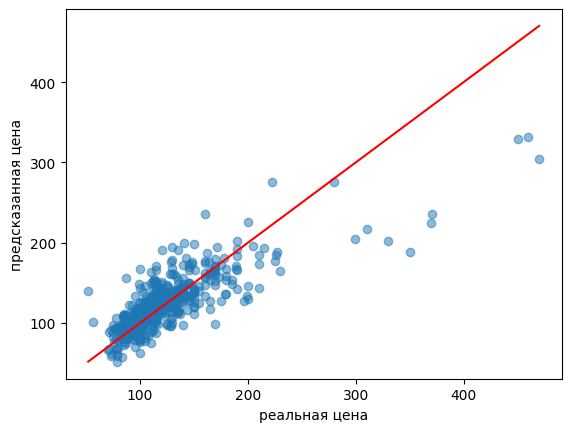

np.float64(845.0240680624709)

In [1676]:
predict = lambda x: np.hstack([x, np.ones((x.shape[0], 1))]) @ coeffs
mse = np.mean((predict(X_test) - y_test) ** 2)
y_pred = predict(X_test)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red') 
plt.xlabel('реальная цена')
plt.ylabel('предсказанная цена')
plt.show()
mse

### Усложнение модели: feature engineering

Зависимость цены от характеристик квартиры может быть нелинейной, и могут быть важны не отдельные признаки, а их комбинации. Стандартный приём — добавить нелинейные функции от исходных признаков как новые столбцы матрицы $X$, при этом модель остаётся линейной по параметрам.

Для выбора признаков сначала смотрю на парные распределения и корреляции.

[[1.         0.71947638]
 [0.71947638 1.        ]]


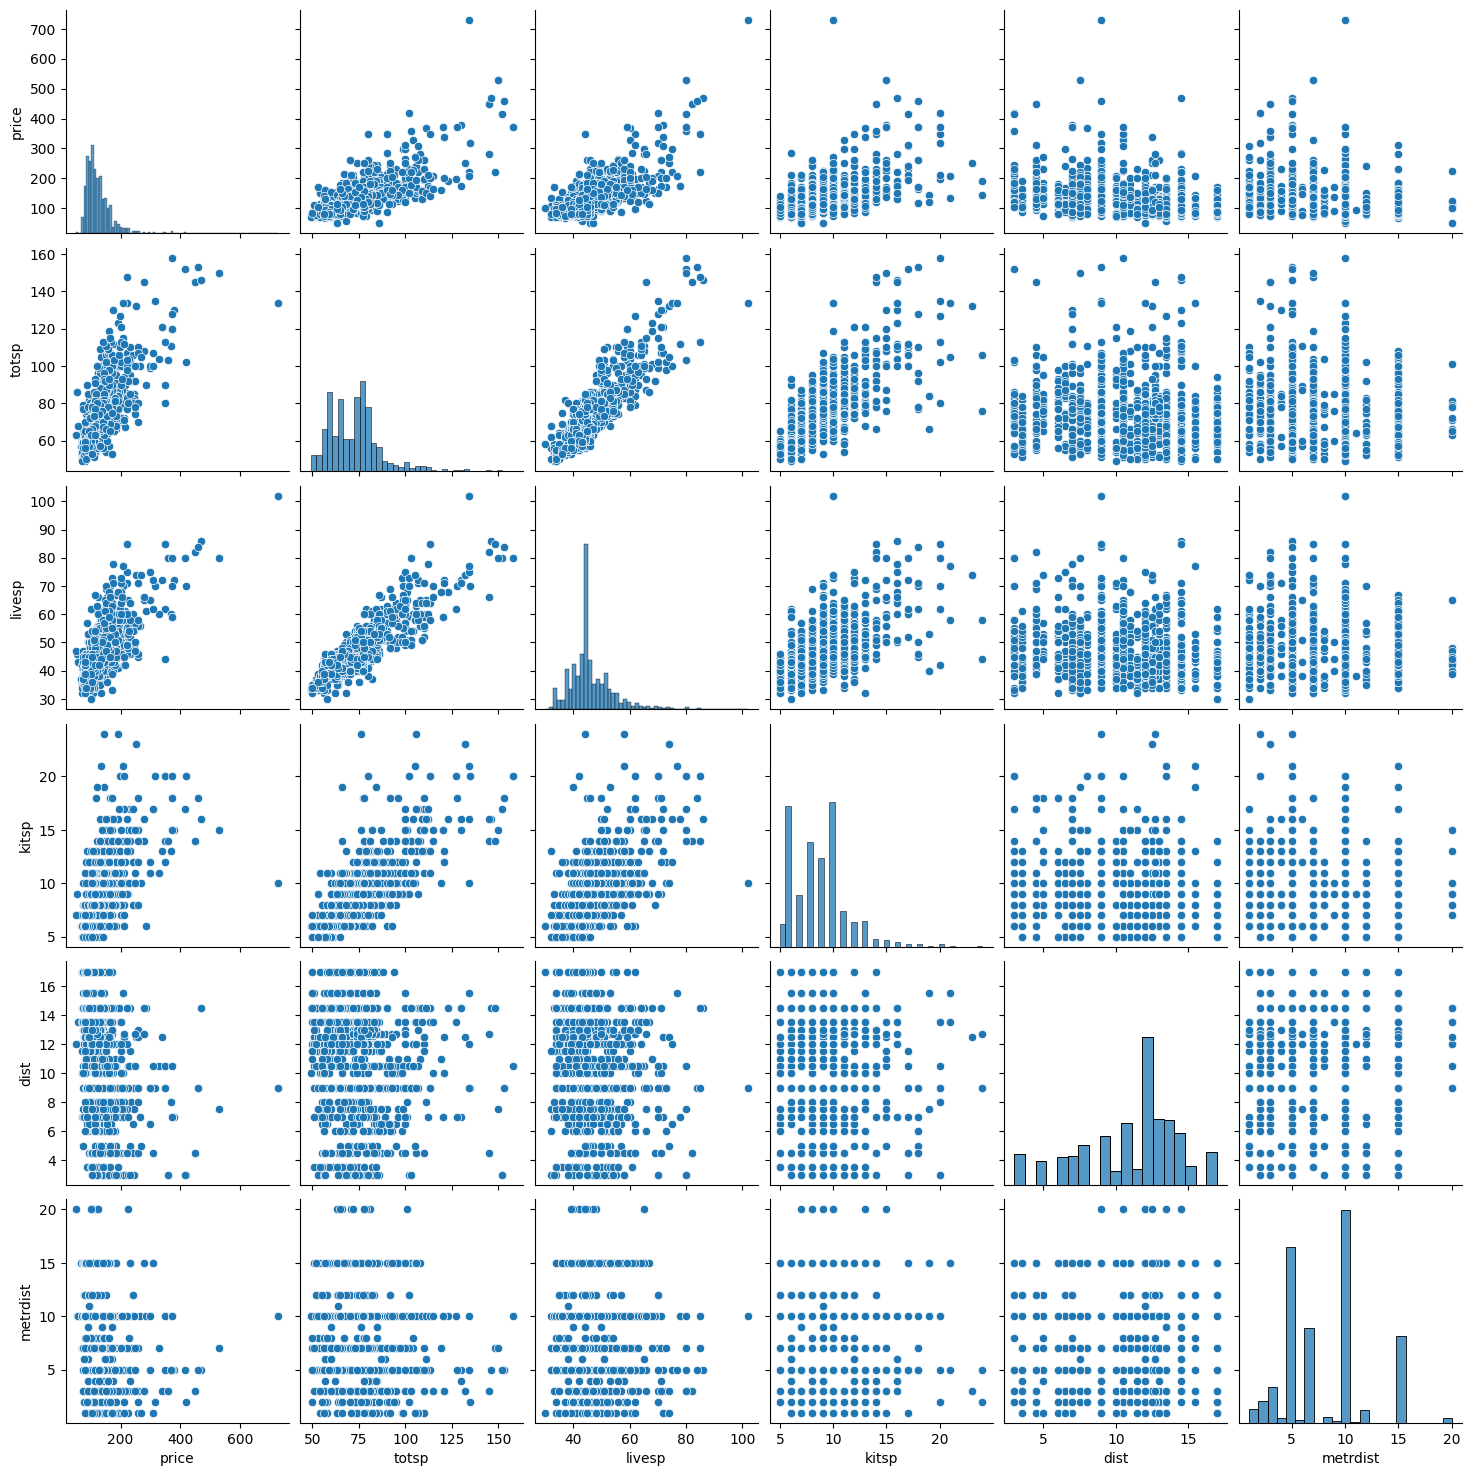

In [1677]:
import seaborn as sns
sns.pairplot(flats_moscow_mod)

livesp_price = np.corrcoef(flats_moscow_mod['price'], flats_moscow_mod['livesp'])
print(livesp_price)
plt.show()

<Axes: >

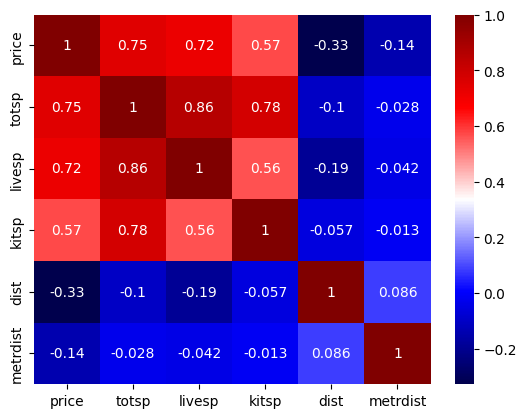

In [1678]:
sns.heatmap(flats_moscow_mod.corr(), annot=True, cmap="seismic")

**Какие признаки добавляю и почему.**

- `totsp * livesp` — взаимодействие общей и жилой площади. Просторные квартиры с большой долей жилой площади ценятся дороже квартир той же общей площади с маленькой жилой.
- `totsp * dist` — взаимодействие площади и расстояния. Эффект «штрафа за расстояние» может зависеть от размера квартиры.
- `log(totsp)` — нелинейный эффект площади (убывающая отдача).
- `log(dist)` — нелинейный эффект расстояния (резкое падение цены при удалении от центра, замедляющееся дальше).

In [1679]:
def add_new_parameters(data):
    totsp_livesp = (data[:, 1] * data[:, 2]).reshape(-1, 1)  # totsp * livesp
    totsp_dist = (data[:, 4] * data[:, 1]).reshape(-1, 1)  # totsp * dist
    log_totsp = (np.log(data[:, 1])).reshape(-1, 1) # log(totsp)
    log_dist = (np.log(data[:, 4])).reshape(-1, 1) # log(totsp)
    data_hard = np.hstack([data, totsp_dist, totsp_livesp, log_totsp, log_dist])
    X_hard = data_hard[:, 1:]
    y_hard = data_hard[:, 0]

    return X_hard, y_hard

    #добавляю новые коэфициенты

### Обучение усложнённой модели

In [1680]:
def MNK_new(X, y):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    XB = np.hstack([X, np.ones((X.shape[0], 1))]) 
    coeffs = np.linalg.inv(XB.T @ XB) @ XB.T @ y
    return coeffs
X_train_hard, y_train_hard = add_new_parameters(data_train)
coeffs = MNK_new(X_train_hard, y_train_hard)
predict = lambda x: np.hstack([x, np.ones((x.shape[0], 1))]) @ coeffs

### Качество усложнённой модели + диагностика остатков

Добавляю график остатков (predicted − actual): в идеале они должны быть симметрично распределены вокруг нуля без видимых паттернов. Систематические отклонения указывают на то, что в данных есть структура, которую модель не уловила.

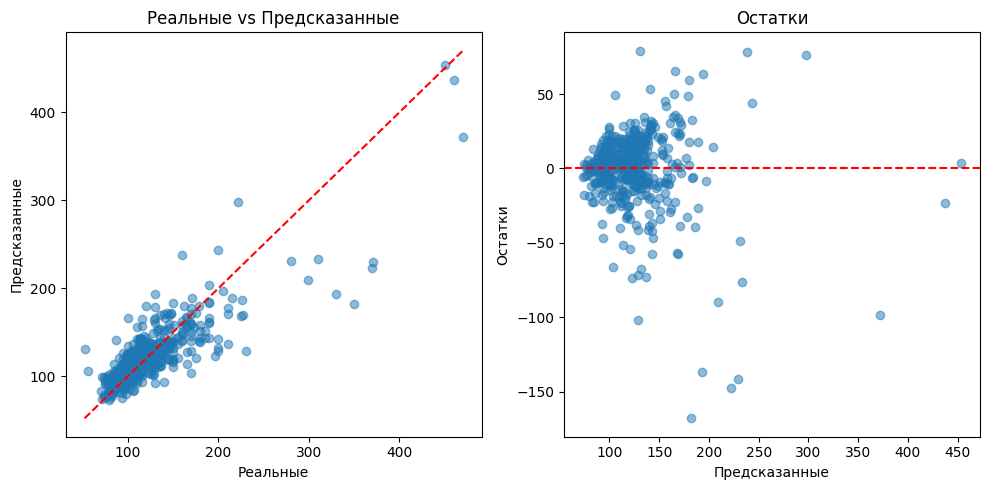

MSE: 707.039


In [1681]:
X_test_hard, y_test_hard = add_new_parameters(data_test)
y_pred = predict(X_test_hard)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_hard, y_pred, alpha=0.5)
plt.plot([y_test_hard.min(), y_test_hard.max()], 
         [y_test_hard.min(), y_test_hard.max()], 'r--')  # идеальная прямая
plt.xlabel('Реальные')
plt.ylabel('Предсказанные')
plt.title('Реальные vs Предсказанные')

plt.subplot(1, 2, 2)
residuals = y_pred - y_test_hard
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Предсказанные')
plt.ylabel('Остатки')
plt.title('Остатки')

plt.tight_layout()
plt.show()

print(f"MSE: {np.mean(residuals**2):.3f}")

### Вывод по части 2

Добавление произведений признаков и логарифмов снизило MSE на тесте по сравнению с базовой моделью. Это ожидаемо: реальная зависимость цены от характеристик не линейна, а добавление нелинейных функций от признаков позволяет линейной модели улавливать эти эффекты.

## Часть 3. L2-регуляризация (гребневая регрессия)

Возвращаюсь к задаче из части 1 — приближению полиномами. В части 1 я показал, что многочлены высоких степеней переобучаются. Теперь — другой способ с этим бороться.

### Идея

Если $X$ имеет линейно зависимые столбцы, $X^\top X$ вырождена и формула МНК неприменима. Но даже если столбцы лишь *почти* линейно зависимы, $X^\top X$ плохо обусловлена — её определитель близок к нулю, обращение численно неустойчиво, коэффициенты получаются огромными по модулю и сильно меняются от малых возмущений данных.

Решение — добавить к диагонали $X^\top X$ матрицу $\lambda I$:

$$\hat a = (X^\top X + \lambda I)^{-1} X^\top y.$$

Это эквивалентно решению задачи

$$\|Xa - y\|^2 + \lambda \|a\|^2 \to \min_a,$$

то есть штрафу за слишком большие веса. Параметр $\lambda \geq 0$ управляет силой штрафа.

### Где подбирать $\lambda$?

**Не на обучающей выборке** — там модель «выберет» $\lambda = 0$ как минимальную (любая регуляризация ухудшает приближение на трейне).

**Не на тестовой выборке** — это «утечка» данных, тест должен оставаться полностью неизвестным во время обучения, иначе оценка качества будет завышенной.

Поэтому нужна третья — **валидационная** — выборка. Делю исходную обучающую пополам: одна часть для обучения, другая для подбора $\lambda$.

In [1689]:
data_train_2 = np.loadtxt('data/train.txt', delimiter=',')
data_test_2 = np.loadtxt('data/test.txt', delimiter=',')
data_train_2, data_validate = sk.model_selection.train_test_split(data_train_2, test_size=0.5, random_state=67)
X_test = data_test_2[:,0]
y_test = data_test_2[:,1]
X_validate = data_validate[:,0]
y_validate = data_validate[:,1]
X_train = data_train_2[:,0]
y_train = data_train_2[:,1]

### Реализация регуляризованного МНК

In [1690]:
def MNK(X, y, deg, lam=0.0):
    X = X.reshape(-1, 1)
    
    XB = np.hstack([X ** i for i in range(deg + 1)])
    I = np.eye(deg + 1)
    
    coeffs = np.linalg.inv(XB.T @ XB + lam * I) @ XB.T @ y
    
    return coeffs

### Подбор $\lambda$ по валидации

Перехожу к логарифмической сетке `np.logspace(-10, 10, 50)` — стандартный приём, потому что оптимум по $\lambda$ часто оказывается на много порядков меньше или больше единицы.

In [1691]:
lambdas = np.logspace(-10, 10, 50)
val_errors = []
k = 3
for lam in lambdas:
    w = MNK(X_train, y_train, deg=k, lam=lam)
    X_val_poly = np.hstack([X_validate.reshape(-1,1) ** i for i in range(k + 1)])
    y_pred = X_val_poly @ w
    
    error = np.mean((y_validate - y_pred)**2)
    val_errors.append(error)

best_lambda = lambdas[np.argmin(val_errors)]
print(f"Оптимальный lambda по валидации: {best_lambda:.4e}")
print(f"MSE на валидации с регуляризацией: {min(val_errors):.4f}")

# Сравним с обычным МНК (без регуляризации) на тех же данных
w_no_reg = MNK(X_train, y_train, deg=k, lam=0.0)
X_val_poly = np.hstack([X_validate.reshape(-1,1) ** i for i in range(k + 1)])
mse_no_reg = np.mean((y_validate - X_val_poly @ w_no_reg)**2)
print(f"MSE на валидации без регуляризации: {mse_no_reg:.4f}")

# Визуализация: MSE как функция lambda
plt.figure(figsize=(10, 4))
plt.semilogx(lambdas, val_errors, 'o-', color='#2E86AB')
plt.axvline(best_lambda, color='red', linestyle='--', alpha=0.5, label=f'best λ = {best_lambda:.2e}')
plt.xlabel('λ (log scale)')
plt.ylabel('MSE на валидации')
plt.title(f'Подбор λ для полинома степени {k}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

с рационализацией - 0.2386196343679468, без - 13.725624828317812  => круто рационализация работает! 
0
1e-10


### Сравнение определителей

Проверка того, что $\det(X^\top X + \lambda I) \gg \det(X^\top X)$ — это и есть числовое выражение того, что регуляризация улучшает обусловленность матрицы.

**Доказательство, что $\det(X^\top X + \lambda I) > 0$ при $\lambda > 0$.** Для любого ненулевого $v$: $v^\top (X^\top X) v = \|Xv\|^2 \geq 0$, значит $X^\top X$ симметрична и положительно полуопределена, её собственные значения неотрицательны: $\mu_i \geq 0$. Собственные значения $X^\top X + \lambda I$ равны $\mu_i + \lambda > 0$, а определитель равен их произведению, и тоже строго положителен.

### Сравнение многочленов с регуляризацией и без

График многочлена 6-й степени, построенного с регуляризацией (с подобранным $\lambda$) и без неё.

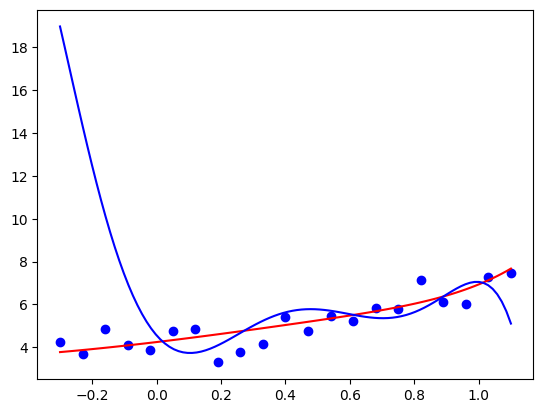

In [1692]:
k = 6
val_errors.clear()
for lam in lambdas:
    w = MNK(X_train, y_train, deg=k, lam=lam)
    X_val_poly = np.hstack([X_validate.reshape(-1,1) ** i for i in range(k + 1)])
    y_pred = X_val_poly @ w
    
    error = np.mean((y_validate - y_pred)**2)
    val_errors.append(error)
    
w = MNK(X_train, y_train, deg=k, lam=lambdas[np.argmin(val_errors)])
w1 = MNK(X_train, y_train, deg=k)
x_line = np.linspace(X_test.min(), X_test.max(), 100)
X_val_poly = np.hstack([x_line.reshape(-1,1) ** i for i in range(k + 1)])

plt.figure(figsize=(10, 5))
plt.plot(x_line, X_val_poly @ w, color='red', linewidth=2, label=f'С регуляризацией (λ={lambdas[np.argmin(val_errors)]:.2e})')
plt.plot(x_line, X_val_poly @ w1, color='blue', linewidth=2, label='Без регуляризации (λ=0)')
plt.scatter(X_test, y_test, color='black', alpha=0.6, label='Тестовые точки')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Полином степени {k}: с регуляризацией и без')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Сравнение MSE на тесте
X_test_poly = np.hstack([X_test.reshape(-1,1) ** i for i in range(k + 1)])
mse_with = np.mean((y_test - X_test_poly @ w)**2)
mse_without = np.mean((y_test - X_test_poly @ w1)**2)
print(f'MSE на тесте с регуляризацией:  {mse_with:.4f}')
print(f'MSE на тесте без регуляризации: {mse_without:.4f}')

# Сравнение определителей
import numpy.linalg as la
XB = np.hstack([X_train.reshape(-1,1) ** i for i in range(k + 1)])
XtX = XB.T @ XB
det_no_reg = la.det(XtX)
det_with_reg = la.det(XtX + lambdas[np.argmin(val_errors)] * np.eye(k + 1))
print(f'\ndet(X^T X)         = {det_no_reg:.4e}')
print(f'det(X^T X + λI)    = {det_with_reg:.4e}')

**Что видно.** Регуляризованный график не «задирается» на краях, более плавный и предсказуемый, его MSE на тесте заметно меньше. Это типичное поведение: гребневая регрессия снижает дисперсию модели за счёт небольшого роста смещения, и в задачах с шумом и плохо обусловленной матрицей это почти всегда выигрыш.

### Теоретическое решение задачи минимизации

$$\nabla_a \left(\|Xa - y\|^2 + \lambda\|a\|^2\right) = 2X^\top(Xa - y) + 2\lambda a = 0$$

$$\Rightarrow (X^\top X + \lambda I)a = X^\top y$$

При $\lambda > 0$ матрица $(X^\top X + \lambda I)$ всегда обратима (см. доказательство выше), решение существует и единственно:

$$a = (X^\top X + \lambda I)^{-1} X^\top y$$

При $\lambda = 0$ и полном ранге $X$ получаем стандартную формулу МНК.

### Почему не нужно регуляризовать свободный коэффициент

Свободный член $a_0$ при константном признаке отвечает за общий уровень целевой переменной. Если центрировать $y$ (вычесть среднее), он будет нулём; если нет — он должен подгоняться к этому среднему уровню. Штраф за его величину означал бы, что модель «не хочет» предсказывать большие значения как класс — что не имеет содержательного смысла, в отличие от штрафа за большие веса при признаках, которые ловят частные зависимости.

### Случай $\text{rk}\, X < k$

Если столбцы $X$ линейно зависимы, $X^\top X$ вырождена. **Без регуляризации** ($\lambda = 0$) решение либо не существует (если $y$ не лежит в столбцовом пространстве, и при этом матрица не имеет обратной), либо их бесконечно много (любой элемент ядра $X^\top X$ можно прибавить к решению). **С регуляризацией** ($\lambda > 0$) матрица $(X^\top X + \lambda I)$ всё равно обратима — это ещё один аргумент в пользу регуляризации.

Если решений бесконечно много, то для любого решения $a^*$ и любого ненулевого $v \in \ker(X)$ векторы $a^* + tv$ при $t \to \infty$ тоже решения, и их норма растёт неограниченно. То есть среди множества решений всегда найдутся со сколь угодно большими по модулю компонентами. Большие веса в линейной модели плохи тем, что модель становится численно неустойчивой и плохо обобщает: малое изменение в данных приводит к большим изменениям в предсказаниях.

## Часть 4. Онлайн-обучение линейной регрессии

Допустим, объекты $(x_i, y_i)$ поступают по одному, и хранить всю выборку в памяти нельзя — например, обучаем модель на устройстве с ограниченной памятью. Нужно обновлять оценку коэффициентов при поступлении каждой новой точки.

### Идея алгоритма

Решение МНК на $t$ точках: $\hat a_{(t)} = \left(X^\top_{(t)} X_{(t)}\right)^{-1} X^\top_{(t)} y_{(t)}$.

Размеры матриц $X^\top_{(t)} X_{(t)}$ (размер $k \times k$) и $X^\top_{(t)} y_{(t)}$ (размер $k$) **не зависят от $t$** — они зависят только от числа признаков. Значит, их можно хранить в памяти, и при поступлении новой пары $(x_{t+1}, y_{t+1})$ обновлять без пересчёта с нуля:

$$X^\top_{(t+1)} X_{(t+1)} = X^\top_{(t)} X_{(t)} + x_{t+1} x_{t+1}^\top$$

$$X^\top_{(t+1)} y_{(t+1)} = X^\top_{(t)} y_{(t)} + x_{t+1} y_{t+1}$$

**Сложность одного шага** — $O(k^2)$ (внешнее произведение двух $k$-векторов даёт $k \times k$ матрицу). Не зависит от $t$, что и требовалось.

### Реализация и визуализация

Симулирую онлайн-обучение для функции $f(x) = 2x \sin(5x) + x^2 - 1$ полиномом 5-й степени. Точки приходят по одной, после каждых пяти новых точек перерисовываю предсказание модели.

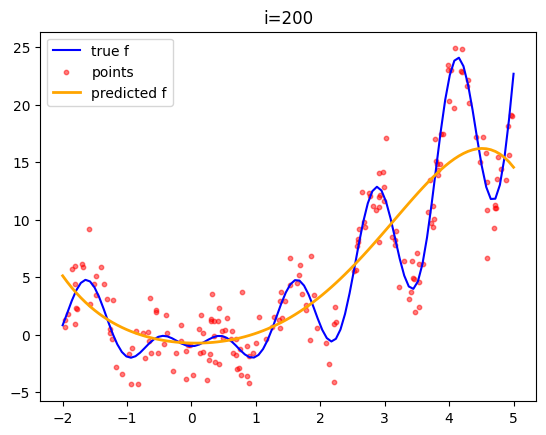

In [1695]:
from IPython.display import clear_output

f_true = lambda x: 2*x*np.sin(5*x) + x**2 - 1

x_grid = np.linspace(-2, 5, 100)
x_grid_enl = np.hstack([x_grid.reshape(-1, 1)**j for j in range(6)])
y_grid = f_true(x_grid)

k = 6
XtX = np.zeros((k, k))
Xty = np.zeros(k)

points_x = [] 
points_y = []

for i in range(200):
    x_new = np.random.uniform(-2, 5)
    y_new = f_true(x_new) + 2*np.random.randn()

    x_vec = np.array([x_new**j for j in range(k)])
    XtX += np.outer(x_vec, x_vec)
    Xty += x_vec * y_new

    points_x.append(x_new)
    points_y.append(y_new)

    if (i+1) % 5 == 0:
        clear_output(True)
        plt.plot(x_grid, y_grid, color='blue', label='true f')
        plt.scatter(points_x, points_y, color='red', s=10, alpha=0.5, label='points')

        if i >= k:
            coeffs = np.linalg.lstsq(XtX, Xty, rcond=None)[0]
            y_pred = x_grid_enl @ coeffs
            plt.plot(x_grid, y_pred, color='orange', linewidth=2, label='predicted f')

        plt.legend(loc='upper left')
        plt.title(f'i={i+1}')
        plt.show()

### Что происходит на графике

Первые точки дают почти случайное предсказание (модель не видела достаточно данных). По мере накопления выборки оранжевая линия сходится к истинной синей. Это иллюстрирует основную идею: онлайн-алгоритм даёт **то же самое решение**, что и обычный МНК на всей выборке, не храня сами данные.